In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

csv_path = "data\play_reviews_sentiment_themes.csv"

df = pd.read_csv(csv_path)

# If date is a string, convert to datetime
if "date" in df.columns:
    df["date"] = pd
    to_datetime(df["date"], errors="coerce")

df.head()


,review_id,review,sentiment_label,sentiment_score,themes,bank
0,28f229b5-0026-41b9-a1eb-b76e74736f63,Make it user friendly.,positive,0.4939,['UI/UX & Features'],CBE
1,68d8daea-db47-4e23-a692-755173dea983,maaliif daddafee install gaafata,neutral,0.0000,['Other'],CBE
2,ee0dbb0e-4eb0-47b5-9874-c37877493f99,good app,positive,0.4404,"['UI/UX & Features', 'Overall Feedback']",CBE
3,5112423d-e618-44ba-ba49-62677cb76cd6,This application is very important and advanta...,positive,0.5198,"['Transactions & Performance', 'UI/UX & Featur...",CBE
4,bcb34681-1dd4-4781-b400-4393bb10b1d9,why didn't work this app?,neutral,0.0000,['UI/UX & Features'],CBE


In [11]:
df.info()

print("\nBank counts:")
print(df["bank"].value_counts())

print("\nSentiment label counts:")
print(df["sentiment_label"].value_counts())

print("\nThemes counts:")
print(df["themes"].value_counts().head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   review_id        1200 non-null   object 
 1   review           1200 non-null   object 
 2   sentiment_label  1200 non-null   object 
 3   sentiment_score  1200 non-null   float64
 4   themes           1200 non-null   object 
 5   bank             1200 non-null   object 
dtypes: float64(1), object(5)
memory usage: 56.4+ KB

Bank counts:
bank
CBE       400
BOA       400
Dashen    400
Name: count, dtype: int64

Sentiment label counts:
sentiment_label
positive    689
neutral     351
negative    160
Name: count, dtype: int64

Themes counts:
themes
['Other']                                             391
['UI/UX & Features']                                  255
['Overall Feedback']                                  215
['UI/UX & Features', 'Overall Feedback']               98
['Transactions &

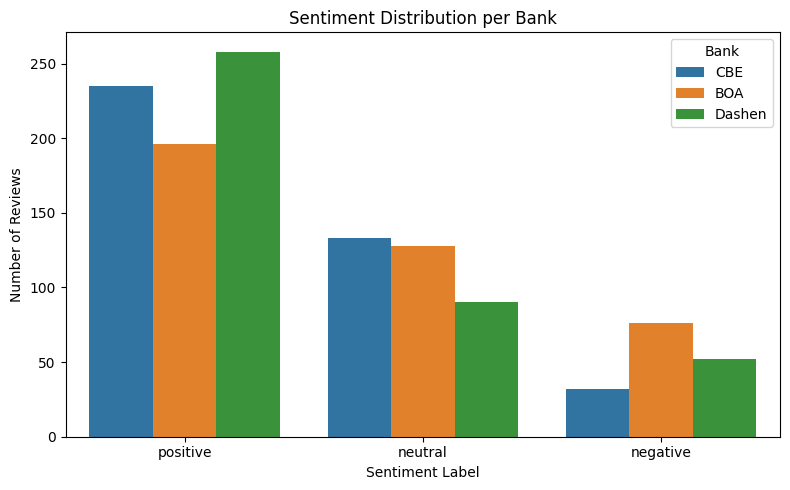

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="sentiment_label", hue="bank")
plt.title("Sentiment Distribution per Bank")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Reviews")
plt.legend(title="Bank")
plt.tight_layout()
plt.show()


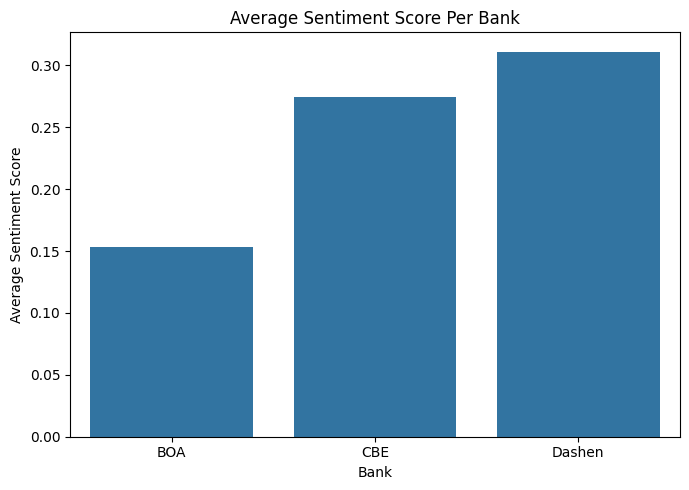

,bank,sentiment_score
0,BOA,0.153618
1,CBE,0.274205
2,Dashen,0.311107


In [13]:
sent_mean = df.groupby("bank")["sentiment_score"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=sent_mean, x="bank", y="sentiment_score")
plt.title("Average Sentiment Score Per Bank")
plt.xlabel("Bank")
plt.ylabel("Average Sentiment Score")
plt.tight_layout()
plt.show()

sent_mean


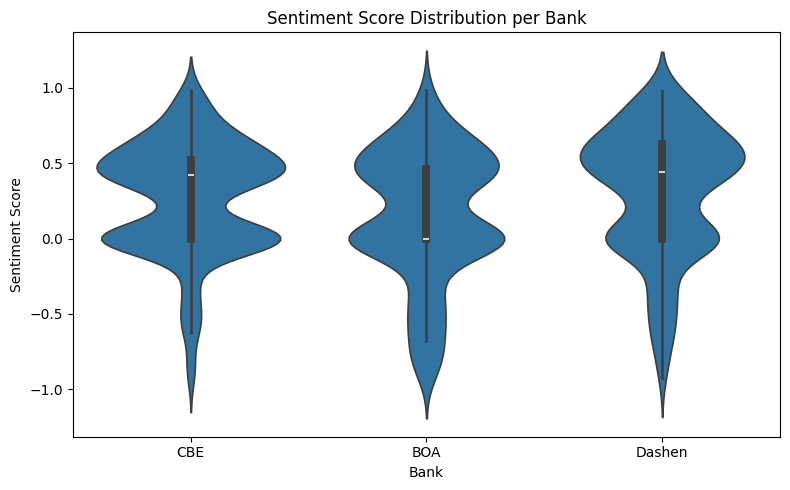

In [14]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="bank", y="sentiment_score")
plt.title("Sentiment Score Distribution per Bank")
plt.xlabel("Bank")
plt.ylabel("Sentiment Score")
plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1660\1374062988.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


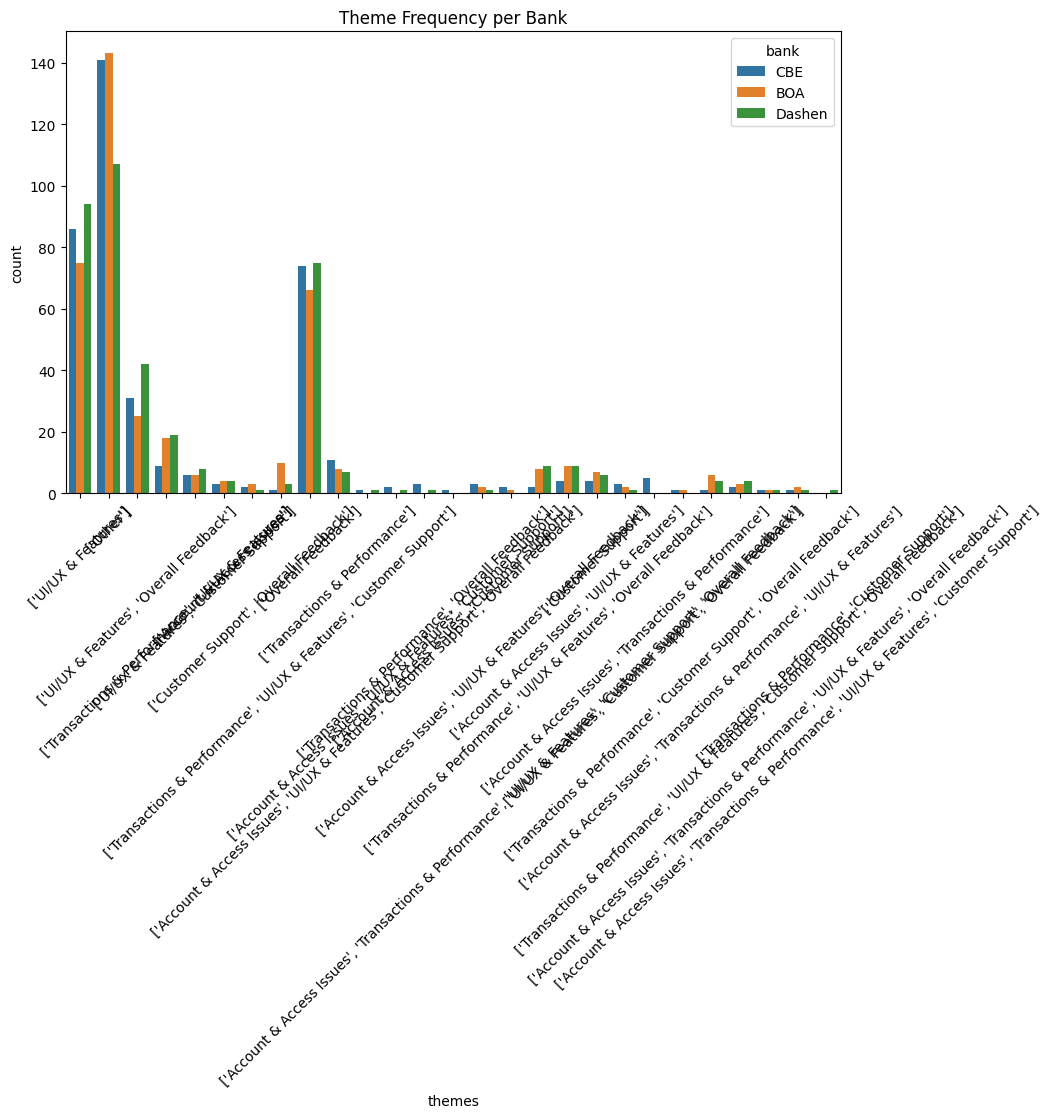

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="themes", hue="bank")
plt.xticks(rotation=45)
plt.title("Theme Frequency per Bank")
plt.tight_layout()
plt.show()


In [16]:
themes_summary = (
    df.groupby(["bank", "themes"])
      .agg(
          review_count=("review", "count"),
          avg_sentiment=("sentiment_score", "mean"),
      )
      .reset_index()
      .sort_values(["bank", "review_count"], ascending=[True, False])
)

themes_summary


,bank,themes,review_count,avg_sentiment
10,BOA,['Other'],143,0.107565
20,BOA,['UI/UX & Features'],75,0.079103
11,BOA,['Overall Feedback'],66,0.456314
19,BOA,"['UI/UX & Features', 'Overall Feedback']",25,0.443960
16,BOA,"['Transactions & Performance', 'UI/UX & Featur...",18,0.115750
...,...,...,...,...
52,Dashen,"['Account & Access Issues', 'UI/UX & Features'...",1,-0.002700
53,Dashen,"['Account & Access Issues', 'UI/UX & Features'...",1,0.401900
56,Dashen,"['Customer Support', 'Overall Feedback']",1,0.440400
60,Dashen,"['Transactions & Performance', 'Customer Suppo...",1,0.085400


In [17]:
drivers = (
    themes_summary
    .sort_values(["bank", "avg_sentiment"], ascending=[True, False])
    .groupby("bank")
    .head(2)
)

pain_points = (
    themes_summary
    .sort_values(["bank", "avg_sentiment"], ascending=[True, True])
    .groupby("bank")
    .head(2)
)

print("Top Drivers (High Sentiment):")
display(drivers)

print("Top Pain Points (Low Sentiment):")
display(pain_points)


Top Drivers (High Sentiment):


,bank,themes,review_count,avg_sentiment
12,BOA,"['Transactions & Performance', 'Customer Suppo...",1,0.565600
8,BOA,"['Customer Support', 'Overall Feedback']",3,0.501900
40,CBE,"['Transactions & Performance', 'UI/UX & Featur...",2,0.840100
22,CBE,"['Account & Access Issues', 'Transactions & Pe...",2,0.813200
68,Dashen,"['UI/UX & Features', 'Overall Feedback']",42,0.533757
62,Dashen,"['Transactions & Performance', 'UI/UX & Featur...",4,0.525275


Top Pain Points (Low Sentiment):


,bank,themes,review_count,avg_sentiment
0,BOA,"['Account & Access Issues', 'Transactions & Pe...",1,-0.93100
4,BOA,"['Account & Access Issues', 'Transactions & Pe...",2,-0.54065
28,CBE,"['Account & Access Issues', 'UI/UX & Features'...",2,-0.42330
31,CBE,['Account & Access Issues'],3,-0.29930
47,Dashen,"['Account & Access Issues', 'Transactions & Pe...",1,-0.92720
50,Dashen,"['Account & Access Issues', 'Transactions & Pe...",1,-0.51060


In [18]:
sent_mean.sort_values("sentiment_score", ascending=False)


,bank,sentiment_score
2,Dashen,0.311107
1,CBE,0.274205
0,BOA,0.153618


In [19]:
drivers


,bank,themes,review_count,avg_sentiment
12,BOA,"['Transactions & Performance', 'Customer Suppo...",1,0.565600
8,BOA,"['Customer Support', 'Overall Feedback']",3,0.501900
40,CBE,"['Transactions & Performance', 'UI/UX & Featur...",2,0.840100
22,CBE,"['Account & Access Issues', 'Transactions & Pe...",2,0.813200
68,Dashen,"['UI/UX & Features', 'Overall Feedback']",42,0.533757
62,Dashen,"['Transactions & Performance', 'UI/UX & Featur...",4,0.525275


In [20]:
pain_points


,bank,themes,review_count,avg_sentiment
0,BOA,"['Account & Access Issues', 'Transactions & Pe...",1,-0.93100
4,BOA,"['Account & Access Issues', 'Transactions & Pe...",2,-0.54065
28,CBE,"['Account & Access Issues', 'UI/UX & Features'...",2,-0.42330
31,CBE,['Account & Access Issues'],3,-0.29930
47,Dashen,"['Account & Access Issues', 'Transactions & Pe...",1,-0.92720
50,Dashen,"['Account & Access Issues', 'Transactions & Pe...",1,-0.51060
